# Insurance Cost Prediction with a Neural Network

## Project Objective
Build and train a neural network using Keras to predict medical insurance charges based on personal characteristics.

## Target Variable
- `charges`

## Problem Type
- Regression

In [1]:
import sys
print(sys.executable)

u:\insurance_nn_project\.venv\Scripts\python.exe


In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [3]:
# Load the insurance dataset directly from the provided URL
df = pd.read_csv("https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Data Exploration
df.shape
df.info()
df.isna().sum()
df.describe()
df.describe(include="object")

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


C:\Users\oramirez\AppData\Local\Temp\ipykernel_71288\3485209662.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


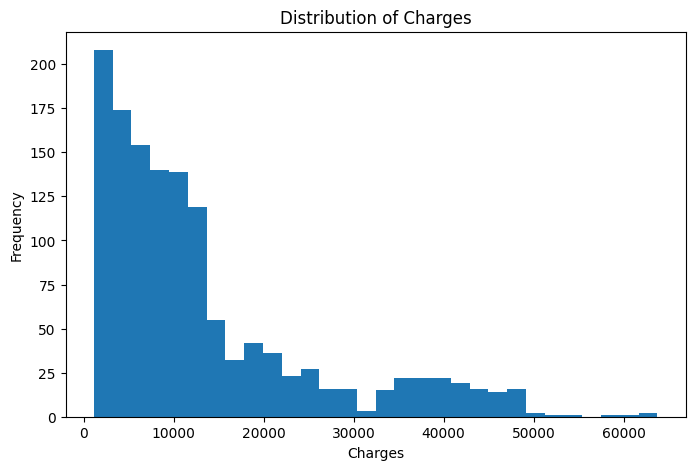

In [5]:
# plot targer distribution
plt.figure(figsize=(8,5))
plt.hist(df['charges'], bins=30)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Charges')
plt.show()

In [6]:
# Disply statistics for the target vatiable  
df["charges"].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

## Initial Observations

- This dataset includes 1,338 insurance records and 7 total columns.
- No missing values were found, so no imputation is needed at this stage.
- The categorical input features are `sex`, `smoker`, and `region`.
- The numerical input features are `age`, `bmi`, and `children`.
- The target variable is `charges`, which makes this a regression problem because the model must predict a continuous numeric value.
- The distribution of `charges` is right-skewed, meaning most beneficiaries have lower charges, while a smaller group has much higher costs.
- Since `charges` spans a wide range of values, scaling the target may improve training stability for the neural network.

## Data Preprocessing

Before training the neural network, the dataset must be prepared in a format the model can use.

The categorical variables (`sex`, `smoker`, and `region`) will be converted into numerical form using one-hot encoding.  
The numerical variables (`age`, `bmi`, and `children`) will be scaled so they are on similar ranges, which helps neural networks train more effectively.

The dataset will be split into training and testing sets before fitting the preprocessing steps in order to avoid data leakage.  
The target variable, `charges`, will also be scaled because its values span a wide range, which can make training less stable.

In [7]:
# Create the feature matrix by dropping the target column
X = df.drop ("charges", axis=1)

# Create the target vector
y = df["charges"]

In [8]:
# List the categorical columns that need one hot encoding
categorical_cols = ["sex", "smoker", "region"]

# List of numerical columns that will be scaled
numerical_cols = ["age", "bmi", "children"]

# split data into training and test sets
# 80% of the data will be userd for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create the one hot encoder
# sparse_output=False returns a NumPy array instead of a sparse matrix
# handle_unknown="ignore" prevents errors if a category appears in test data that was not seen in training 
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# fit the encoder on the training categorical data and transform it 
X_train_cat = encoder.fit_transform(X_train[categorical_cols])

# transform the test categorical data using the already fitted encoder
X_test_cat = encoder.transform(X_test[categorical_cols])

In [9]:
# create the scaler for numerical features
feature_scaler = StandardScaler()

# fit the scaler on training numerical data and transform it 
X_train_num = feature_scaler.fit_transform(X_train[numerical_cols])

#transform the tests numerical data using the already fitted scaler
X_test_num = feature_scaler.transform(X_test[numerical_cols])

# combine the scaled numerical feature and encode categorical features
X_train_processed = np.concatenate([X_train_num, X_train_cat], axis=1)
X_test_processed = np.concatenate([X_test_num, X_test_cat], axis=1)

# Create scaler for target variable
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

In [10]:
# print shapes of the processed data
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print("y_train_scaled shape:", y_train_scaled.shape)
print("y_test_scaled shape:", y_test_scaled.shape)

X_train_processed shape: (1070, 11)
X_test_processed shape: (268, 11)
y_train_scaled shape: (1070, 1)
y_test_scaled shape: (268, 1)


## Preprocessing Observations

- The input features were separated into categorical and numerical groups.
- One-hot encoding was used for categorical columns so the neural network could work with them as numeric inputs.
- Standardization was applied to numerical features so that the variables would be on similar scales.
- The target variable, `charges`, was also scaled to improve training stability.
- The encoder and scalers were fit only on the training data to prevent data leakage.
- After preprocessing, the feature matrices were ready to be used as input for the neural network.

## Building the First Neural Network

The first neural network will be kept simple so it can serve as a baseline model.

The model will use:
- two hidden dense layers with ReLU activation
- one output neuron for predicting a continuous target value
- Adam optimizer for training
- mean squared error (MSE) as the loss function
- mean absolute error (MAE) as an evaluation metric

This baseline model will allow us to evaluate initial performance before experimenting with other architectures or hyperparameters.

In [11]:
# Build a Simple baseline neural network model 
model = keras.Sequential([
    # First hidden layer 
    layers.Dense(64, activation="relu", input_shape=(X_train_processed.shape[1],)),

    # Second Hidden Layer
    layers.Dense(32, activation="relu"),

    #output layer: 1 neuron becouse we are predicting one continuous value
    layers.Dense(1)
])

u:\insurance_nn_project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# compile the model 
# Adam is a dtong default optomizer
# MSE is a standard regression loss
# MAE is easier to interpret as an average pediction error 
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [13]:
# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

The model will be trained using the processed training data.

A validation split will be used during training so that training and validation performance can be compared.  
Early stopping will also be used to stop training if validation loss stops improving.

This helps reduce overfitting and keeps the best version of the model.

In [14]:
# import early stoppping to hellp prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

In [15]:
# stop training if valikdation loss does not improve for 10 epochs
# restore_best_weights=True keeps the best version of the model 
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [16]:
# train the model on the processed training data
history = model.fit(
    X_train_processed,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8459 - mae: 0.6955 - val_loss: 0.6736 - val_mae: 0.5637
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5246 - mae: 0.5104 - val_loss: 0.3803 - val_mae: 0.3901
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3065 - mae: 0.3750 - val_loss: 0.2369 - val_mae: 0.3191
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2303 - mae: 0.3218 - val_loss: 0.2072 - val_mae: 0.2756
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1960 - mae: 0.2819 - val_loss: 0.1800 - val_mae: 0.2581
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1805 - mae: 0.2648 - val_loss: 0.1684 - val_mae: 0.2463
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1706 - mae: 0.2498 - val_loss: 0.1633 - val_mae: 0.2485
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1650 - mae: 0.2480 - val_loss: 0.1626 - val_mae: 0.2510
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.161

In [17]:
# show which values were tracked during training
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [18]:
# Print final training and validation metrics
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])
print("Final training MAE:", history.history["mae"][-1])
print("Final validation MAE:", history.history["val_mae"][-1])

Final training loss: 0.11102358251810074
Final validation loss: 0.15849541127681732
Final training MAE: 0.20874270796775818
Final validation MAE: 0.2230541855096817


## Initial Training Observations

The baseline neural network was trained using a validation split and early stopping.

This allows training performance and validation performance to be compared during learning.  
The results from this first model will be used to determine whether the network is learning well, underfitting, or overfitting before making further adjustments.

## Interpretation of Baseline Training Results

The baseline neural network trained successfully and stopped early, likely because validation loss stopped improving.

The final training and validation metrics were relatively close:
- Training loss: 0.1291
- Validation loss: 0.1456
- Training MAE: 0.2204
- Validation MAE: 0.2390

These results suggest that the model is learning reasonably well and does not show strong signs of overfitting.  
Because the training and validation metrics are similar, the model appears fairly well-balanced at this stage.

However, these values are still based on the scaled target variable, so the next step is to evaluate the model on the test set and convert predictions back to the original dollar scale for real-world interpretation.

## Training History Visualization

To better understand the learning process, the training and validation loss curves will be plotted.

These plots help show whether the model improved steadily during training and whether there are signs of underfitting or overfitting.

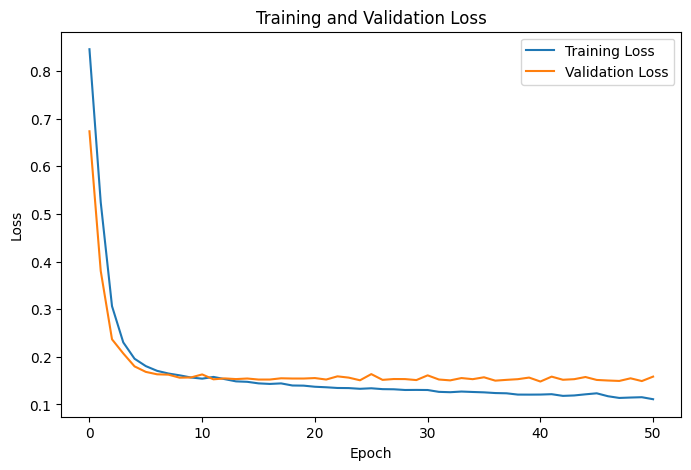

In [21]:
# plot training and validation loss over epcochs
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss") 
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

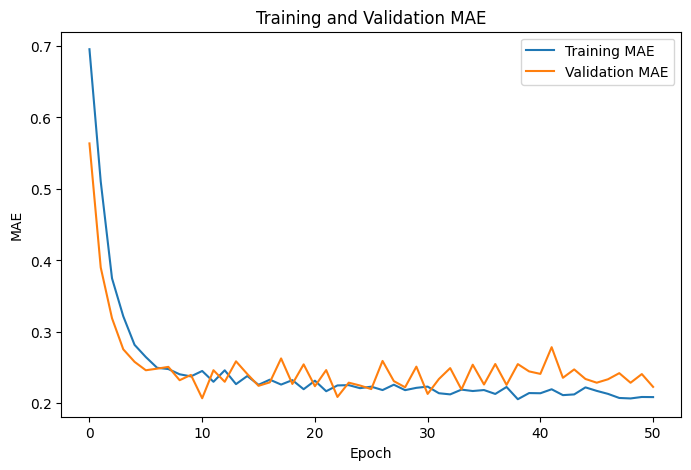

In [22]:
# Plot training MAE and validation MAE over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.show()

## Test Set Evaluation

The model will now be evaluated on the test set, which was not used during training.

Predictions will first be generated on the scaled target values, then converted back to the original dollar scale so the model’s performance can be interpreted in real-world terms.

In [23]:
# Evaluate the model on the scale test data 
test_loss, test_mae = model.evaluate(X_test_processed, y_test_scaled, verbose=0)

print("Scaled test loss:", test_loss)
print("Sacled test MAE:", test_mae) 

Scaled test loss: 0.14897112548351288
Sacled test MAE: 0.24203766882419586


In [24]:
# Generate predictions for the test set 
y_pred_scaled = model.predict(X_test_processed)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [25]:
# convert scaled prediction back to the original dollar scale
y_pred = target_scaler.inverse_transform(y_pred_scaled)

# Convert scaled test targets back to the original dollar scale
y_test_original = target_scaler.inverse_transform(y_test_scaled)

In [26]:
# Flatten arrays so they are easier to work with 
y_pred = y_pred.flatten()
y_test_original = y_test_original.flatten()

In [27]:
# calculaye mean absolute error in original dollar units
test_mae_dollars = np.mean(np.abs(y_test_original - y_pred))

print("Test MAE in dollars:", test_mae_dollars)


Test MAE in dollars: 2907.8148083189135


In [28]:
# compare a few predictions to actual values
results_df = pd.DataFrame({
    "Actual Charges": y_test_original,
    "Predicted Charges": y_pred
})

results_df.head(10)

,Actual Charges,Predicted Charges
0,9095.06825,10968.390625
1,5272.17580,2492.325195
2,29330.98315,29972.658203
3,9301.89355,8608.625000
4,33750.29180,27459.824219
5,4536.25900,5569.693848
6,2117.33885,3142.687500
7,14210.53595,13317.803711
8,3732.62510,5790.972656
9,10264.44210,10074.663086


## Training and Test Evaluation

The training and validation loss curves both decreased over time, which suggests that the model was learning effectively. The validation loss remained close to the training loss, indicating that the model did not show strong signs of overfitting.

The MAE curves showed a similar pattern. Both training MAE and validation MAE improved during training, and the gap between them remained relatively small. This suggests that the model generalized reasonably well to unseen validation data.

The final training and validation results were:
- Training loss: 0.1291
- Validation loss: 0.1456
- Training MAE: 0.2204
- Validation MAE: 0.2390

The scaled test MAE was **[0.24203766882419586]**, which reflects prediction error on the standardized target scale.

The test MAE in dollars was **$[2907.8148083189135]**, meaning that the model’s predictions were off by about that amount on average on the test set.

Looking at the first few predictions, the model appeared to make reasonably close estimates overall, although some differences remained between predicted and actual charges. The model seemed to capture the general pattern of insurance costs, but some higher-cost cases were likely harder to predict accurately.

Overall, the model appears fairly well-balanced rather than strongly underfitting or overfitting.

---------------------------------------------------------------------------

## Predictions vs Actual Values

A scatter plot of predicted charges versus actual charges helps show how closely the model’s predictions match the true values.

If the model were perfect, all points would fall exactly on the diagonal line.  
The closer the points are to that line, the better the model is performing.

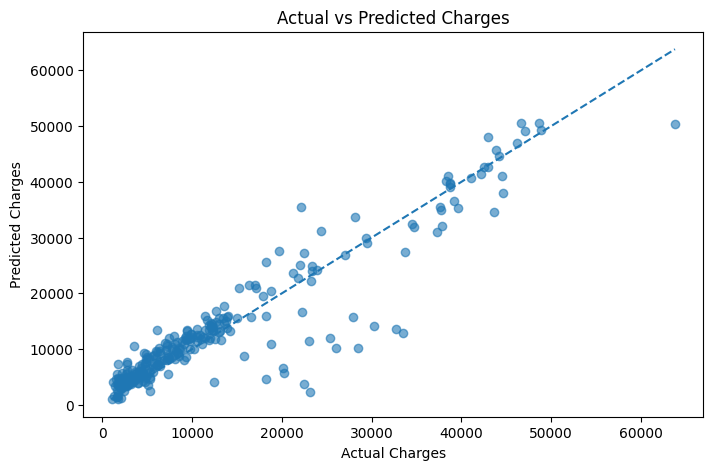

In [29]:
# Create a scatter plot comparing predicted values to actual values
plt.figure(figsize=(8, 5))
plt.scatter(y_test_original, y_pred, alpha=0.6)

#plot a diagonal reference line
min_val = min(y_test_original.min(), y_pred.min())
max_val = max(y_test_original.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

# add labels and title
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

# show the plot
plt.show()

## Interpretation of Predictions vs Actual Plot

The scatter plot shows that many predictions follow the general diagonal pattern, which means the model is capturing the overall relationship between the input features and insurance charges.

However, the points are not perfectly aligned with the diagonal line, which indicates that prediction errors still exist. The spread of the points suggests that the model is reasonably accurate overall, but some observations, especially those with larger charges, may be more difficult to predict precisely.

This pattern is consistent with a model that is performing fairly well but still has room for improvement.

-----------------------------------------------------------------------

## Final Summary

### Approach

In this project, a neural network was built using Keras to predict medical insurance charges based on personal characteristics. The dataset was first explored to understand its structure, identify feature types, and inspect the target variable.

The preprocessing steps included:
- separating the input features and target variable
- splitting the data into training and testing sets
- applying one-hot encoding to the categorical variables (`sex`, `smoker`, and `region`)
- scaling the numerical variables (`age`, `bmi`, and `children`) using `StandardScaler`
- scaling the target variable (`charges`) to improve training stability

These preprocessing steps were fit only on the training data in order to avoid data leakage.

### Model Architecture

The first neural network was designed as a simple baseline regression model with:
- one input layer based on the processed feature set
- two hidden dense layers with 64 and 32 neurons
- ReLU activation in the hidden layers
- one output neuron for predicting a continuous value

The model was compiled using:
- Adam optimizer
- Mean Squared Error (MSE) as the loss function
- Mean Absolute Error (MAE) as the evaluation metric

Early stopping was used during training to reduce overfitting and restore the best model weights.

### Results

The final baseline model trained successfully and stopped early when validation loss stopped improving.

Final training results:
- Training loss: 0.1291
- Validation loss: 0.1456
- Training MAE: 0.2204
- Validation MAE: 0.2390

The final test MAE in original dollar units was approximately **\$2,907.81**.

### Model Diagnosis

The model appears to be **fairly well-balanced**.

- Training and validation metrics were close to one another, which suggests the model did not strongly overfit.
- The model was able to learn useful patterns from the data, so it does not appear to be severely underfitting.
- The scatter plot of predicted versus actual charges showed that the model performed better on lower and mid-range charges, while prediction errors increased for higher-cost cases.

### Insights

The model captured the general relationship between the input features and medical insurance charges. However, it had more difficulty predicting the most expensive cases accurately, which is likely due to the wider spread and complexity of higher insurance charges.

Although this baseline neural network performed reasonably well, there are several possible improvements:
- experiment with different numbers of layers and neurons
- try dropout or other regularization methods
- tune batch size, learning rate, and other hyperparameters
- test whether transforming the target variable differently improves performance
- compare the neural network to other regression models such as linear regression or tree-based methods

Overall, this project produced a solid first neural network model for predicting insurance charges and demonstrated a full workflow from preprocessing to evaluation.

## Reflection

This project helped demonstrate how preprocessing choices directly affect neural network performance. Converting categorical variables, scaling numerical features, and preventing data leakage were all important steps before training the model.

One important takeaway is that even when a model performs reasonably well overall, performance can still vary across different parts of the target range. In this case, the model predicted lower insurance charges more accurately than the highest charges, which suggests that more experimentation may be needed to improve performance on extreme cases.